# American Sign Language Letters - Training Notebook

Notebook ini melatih model klasifikasi huruf American Sign Language (ASL) menggunakan transfer learning dengan arsitektur **MobileNetV2**.

**Alur kerja:**
1. Load & split dataset
2. Bangun model (frozen base)
3. Training awal (feature extraction)
4. Fine-tuning (unfreeze sebagian layer)
5. Simpan model (SavedModel + TFLite)
6. Visualisasi hasil training

In [ ]:
!pip install pydrive2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import & Konfigurasi

In [ ]:
import itertools
import pathlib
import os.path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [ ]:
import pathlib
import tensorflow as tf

# Pastikan kamu sudah menjalankan drive.mount('/content/drive') sebelumnya

# ── Path & file ──────────────────────────────────────────────────────────────
# Mengarah langsung ke folder dataset di Google Drive kamu
DATASET_DIR = pathlib.Path("/content/drive/MyDrive/asl/American_Sign_Language_Letters_Multiclass")

CHECKPOINT_PATH: str = "./checkpoint/"
TFLITE_FNAME: str = "model.tflite"
MODEL_DIAGRAM_PATH: str = "/tmp/"

# ── Dataset ───────────────────────────────────────────────────────────────────
BATCH_SIZE: int = 64
IMAGE_SIZE: tuple = (160, 160)
IMAGE_SHAPE: tuple = IMAGE_SIZE + (3,)
VALIDATION_SPLIT: float = 0.2

# ── Augmentation & regularization ────────────────────────────────────────────
DATA_AUGMENTATION_FACTOR: float = 0.03
DROPOUT_RATE: float = 0.2
L2_REGULARIZATION: float = 0.0001

# ── Training awal ─────────────────────────────────────────────────────────────
BASE_LEARNING_RATE: float = 0.005
BASE_LR_DECAY_STEPS: int = 300
BASE_LR_DECAY_RATE: float = 0.85
INITIAL_EPOCHS: int = 64

# ── Fine-tuning ───────────────────────────────────────────────────────────────
FINE_TUNE_LEARNING_RATE: float = 0.00005
FINE_TUNE_LR_DECAY_STEPS: int = 200
FINE_TUNE_LR_DECAY_RATE: float = 0.95
FINE_TUNE_EPOCHS: int = 32
FINE_TUNE_AT: int = 80          # Freeze layer di bawah indeks ini

# ── Early stopping ────────────────────────────────────────────────────────────
EARLYSTOP_MIN_DELTA: float = 0.00001
EARLYSTOP_PATIENCE: int = 3

# ── TFLite ────────────────────────────────────────────────────────────────────
OPTIMIZE_TFLITE: bool = False
NUM_CALIBRATION_EXAMPLES: int = 150

print("Konfigurasi berhasil dimuat.")
print(f"Dataset target: {DATASET_DIR}")

Konfigurasi berhasil dimuat.
Dataset target: /content/drive/MyDrive/asl/American_Sign_Language_Letters_Multiclass


Found 3408 files belonging to 28 classes.


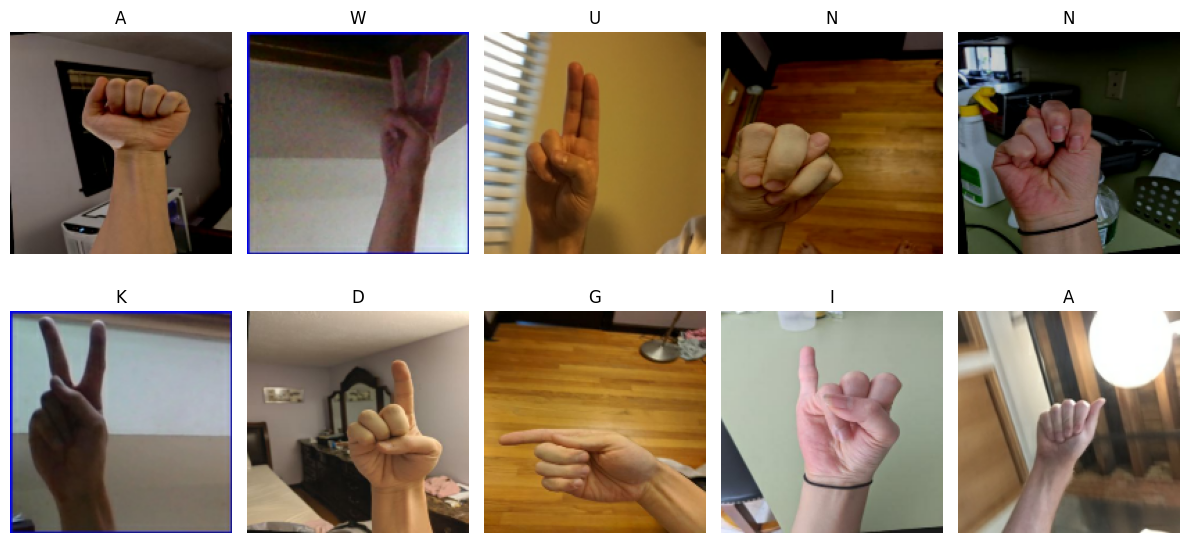

In [ ]:
import matplotlib.pyplot as plt

# 1. Muat dataset untuk mengambil informasi nama kelas (labels)
# Kita set batch_size=10 hanya untuk mengambil 10 sampel pertama dengan cepat
sample_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    batch_size=10,
    image_size=IMAGE_SIZE,
    shuffle=True, # Di-shuffle agar sampel yang muncul bervariasi
    seed=42
)

class_names = sample_ds.class_names

# 2. Ambil 1 batch (berisi 10 gambar dan 10 label)
for images, labels in sample_ds.take(1):
    plt.figure(figsize=(12, 6)) # Mengatur ukuran jendela plot

    for i in range(10):
        ax = plt.subplot(2, 5, i + 1) # Membuat grid 2 baris dan 5 kolom

        # Mengubah tensor gambar ke bentuk unit8 untuk ditampilkan
        plt.imshow(images[i].numpy().astype("uint8"))

        # Menampilkan judul berupa nama kelas asli dari gambar tersebut
        plt.title(class_names[labels[i]])
        plt.axis("off") # Menghilangkan garis koordinat x dan y

    plt.tight_layout()
    plt.show()

In [ ]:
import os

# 1. Hitung jumlah data per kelas (sub-folder)
class_counts = {}
total_images = 0

# Iterasi setiap item di dalam folder dataset
for item in sorted(os.listdir(DATASET_DIR)):
    item_path = os.path.join(DATASET_DIR, item)

    # Pastikan yang dibaca adalah folder (bukan file tersembunyi seperti .DS_Store)
    if os.path.isdir(item_path):
        # Hitung jumlah file gambar di dalam folder kelas ini (png, jpg, jpeg, bmp)
        img_count = len([f for f in os.listdir(item_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
        class_counts[item] = img_count
        total_images += img_count

print("="*50)
print(f" RANGKUMAN DATASET: {DATASET_DIR.name}")
print("="*50)
print(f"Total Kelas  : {len(class_counts)} kelas")
print(f"Total Gambar : {total_images} gambar")
print("="*50)

 RANGKUMAN DATASET: American_Sign_Language_Letters_Multiclass
Total Kelas  : 28 kelas
Total Gambar : 3408 gambar


In [ ]:
import pandas as pd

# 2. Membuat DataFrame untuk Tabel Distribusi
df_dist = pd.DataFrame(list(class_counts.items()), columns=['Nama Kelas', 'Jumlah Gambar'])
df_dist['Persentase (%)'] = (df_dist['Jumlah Gambar'] / total_images * 100).round(2)

# Menambahkan baris Total di bagian paling bawah tabel
df_total = pd.DataFrame([['TOTAL DATASET', total_images, 100.00]], columns=['Nama Kelas', 'Jumlah Gambar', 'Persentase (%)'])
df_summary_table = pd.concat([df_dist, df_total], ignore_index=True)

print("TABEL DISTRIBUSI KELAS:")
display(df_summary_table)

TABEL DISTRIBUSI KELAS:


,Nama Kelas,Jumlah Gambar,Persentase (%)
0,A,135,3.96
1,B,111,3.26
2,C,121,3.55
3,D,130,3.81
4,E,127,3.73
5,F,130,3.81
6,G,130,3.81
7,H,123,3.61
8,I,142,4.17
9,J,150,4.40


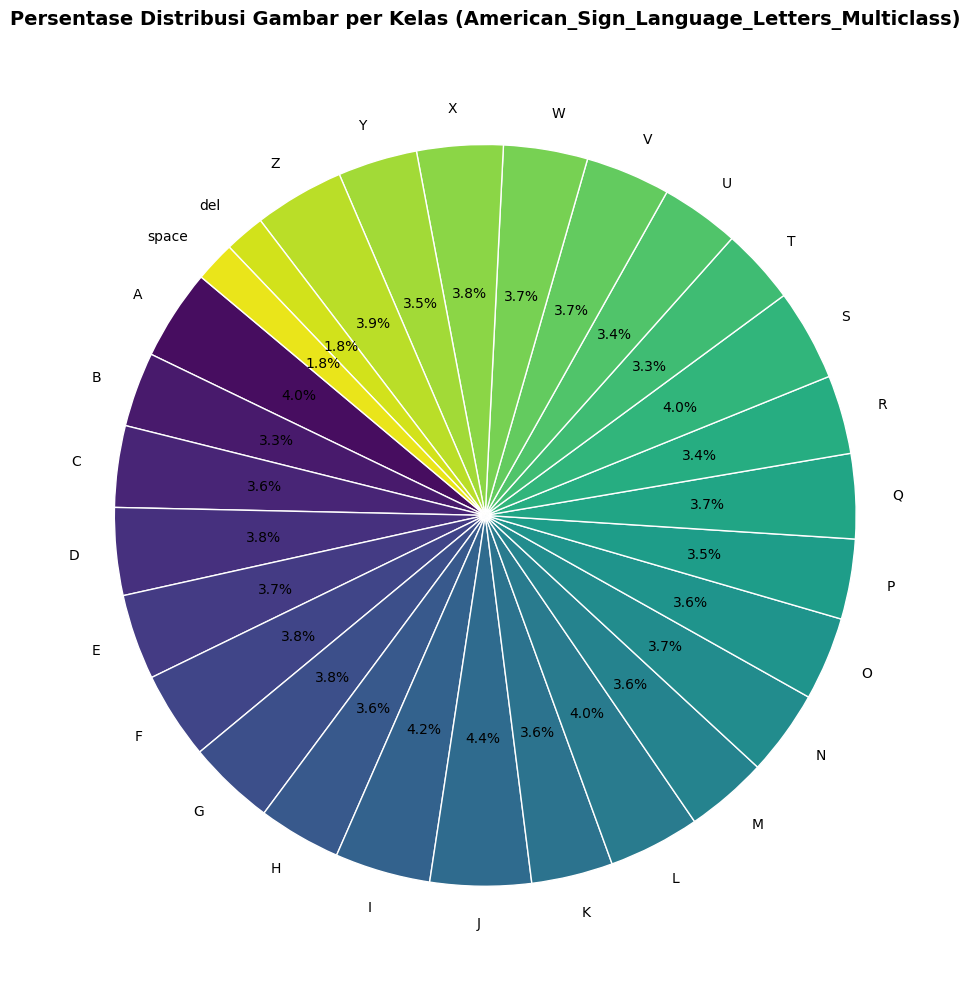

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Visualisasi Distribusi Kelas menggunakan Pie Chart
plt.figure(figsize=(10, 10))

# Menggunakan warna dari palette 'viridis' agar konsisten dan estetik
colors = sns.color_palette('viridis', len(df_dist))

# Membuat Pie Chart
plt.pie(
    df_dist['Jumlah Gambar'],
    labels=df_dist['Nama Kelas'],
    autopct='%1.1f%%',          # Menampilkan persentase di dalam potongan pie
    startangle=140,             # Menentukan sudut awal rotasi lingkaran
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'antialiased': True} # Memberi garis batas antar potongan
)

plt.title(f'Persentase Distribusi Gambar per Kelas ({DATASET_DIR.name})', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## 2. Load & Split Dataset

In [ ]:
def build_dataset(validation_split: float, subset: str) -> tf.data.Dataset:
    return tf.keras.preprocessing.image_dataset_from_directory(
        directory=DATASET_DIR,
        validation_split=validation_split,
        subset=subset,
        seed=123,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
    )


def split_dataset(validation_split: float):
    train_dataset = build_dataset(validation_split, "training")
    validation_dataset = build_dataset(validation_split, "validation")

    class_names = train_dataset.class_names

    train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    validation_dataset = validation_dataset.cache().prefetch(
        buffer_size=tf.data.AUTOTUNE
    )

    return train_dataset, validation_dataset, class_names

In [ ]:
train_dataset, validation_dataset, class_names = split_dataset(VALIDATION_SPLIT)

print(f"Jumlah kelas : {len(class_names)}")
print(f"Nama kelas   : {class_names}")

Found 3408 files belonging to 28 classes.
Using 2727 files for training.
Found 3408 files belonging to 28 classes.
Using 681 files for validation.
Jumlah kelas : 28
Nama kelas   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']


## 3. Bangun Model (Feature Extraction)

In [ ]:
def build_model(num_classes: int):
    """Bangun model dengan MobileNetV2 sebagai base (frozen)."""
    base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
        input_shape=IMAGE_SHAPE,
        include_top=False,
        weights="imagenet",
        pooling="avg",
    )
    tf.keras.utils.plot_model(
        base_model, to_file=MODEL_DIAGRAM_PATH + "base_model.png", show_shapes=True
    )
    base_model.trainable = False  # Freeze semua layer base

    # Data augmentation
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip(mode="horizontal", input_shape=IMAGE_SHAPE),
            tf.keras.layers.RandomRotation(factor=DATA_AUGMENTATION_FACTOR),
            tf.keras.layers.RandomTranslation(
                height_factor=DATA_AUGMENTATION_FACTOR,
                width_factor=DATA_AUGMENTATION_FACTOR,
            ),
            tf.keras.layers.RandomZoom(
                height_factor=DATA_AUGMENTATION_FACTOR,
                width_factor=DATA_AUGMENTATION_FACTOR,
            ),
        ]
    )

    # Bangun model utama
    inputs = tf.keras.Input(shape=IMAGE_SHAPE)
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.Dropout(rate=DROPOUT_RATE)(x)
    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=tf.keras.regularizers.l2(l2=L2_REGULARIZATION),
        name="outputs",
    )(x)
    model = tf.keras.Model(inputs, outputs)
    tf.keras.utils.plot_model(
        model, to_file=MODEL_DIAGRAM_PATH + "fine_tune_model.png", show_shapes=True
    )

    # Learning rate schedule
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        BASE_LEARNING_RATE,
        decay_steps=BASE_LR_DECAY_STEPS,
        decay_rate=BASE_LR_DECAY_RATE,
        staircase=True,
    )

    model.compile(
        optimizer=tf.keras.optimizers.Nadam(learning_rate=lr_schedule),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )

    return base_model, model

In [ ]:
base_model, model = build_model(len(class_names))

print(f"Jumlah layer base model : {len(base_model.layers)}")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Jumlah layer base model : 155


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 28)             │        35,868 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,293,852 (8.75 MB)

 Trainable params: 35,868 (140.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Training Awal (Frozen Base)

In [ ]:
print(f"Jumlah variabel trainable: {len(model.trainable_variables)}")

earlystop_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    min_delta=EARLYSTOP_MIN_DELTA,
    patience=EARLYSTOP_PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    train_dataset,
    callbacks=[earlystop_callback],
    epochs=INITIAL_EPOCHS,
    validation_data=validation_dataset,
)

Jumlah variabel trainable: 2
Epoch 1/64
43/43 ━━━━━━━━━━━━━━━━━━━━ 642s 15s/step - accuracy: 0.2692 - loss: 2.7028 - val_accuracy: 0.4596 - val_loss: 1.7170
Epoch 2/64
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6040 - loss: 1.3268 - val_accuracy: 0.6270 - val_loss: 1.2826
Epoch 3/64
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7253 - loss: 0.9458 - val_accuracy: 0.6593 - val_loss: 1.1705
Epoch 4/64
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7664 - loss: 0.7837 - val_accuracy: 0.7004 - val_loss: 1.0270
Epoch 5/64
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.7770 - loss: 0.7386 - val_accuracy: 0.7078 - val_loss: 0.9843
Epoch 6/64
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8130 - loss: 0.6465 - val_accuracy: 0.7225 - val_loss: 0.9527
Epoch 7/64
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.8181 - loss: 0.6002 - val_accuracy: 0.7592 - val_loss: 0.8735
Epoch 8/64
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.8346 - loss: 0.5

In [ ]:
# Sesuaikan INITIAL_EPOCHS berdasarkan early stopping
if earlystop_callback.stopped_epoch and earlystop_callback.stopped_epoch > 0:
    if earlystop_callback.best_epoch and earlystop_callback.best_epoch > 0:
        INITIAL_EPOCHS = earlystop_callback.best_epoch + 1
    else:
        INITIAL_EPOCHS = earlystop_callback.stopped_epoch + 1

print(f"INITIAL_EPOCHS (setelah early stopping): {INITIAL_EPOCHS}")

INITIAL_EPOCHS (setelah early stopping): 7


## 5. Fine-Tuning

In [ ]:
def fine_tune_model(base_model, model):
    """Unfreeze layer di atas FINE_TUNE_AT dan compile ulang dengan LR kecil."""
    base_model.trainable = True
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        FINE_TUNE_LEARNING_RATE,
        decay_steps=FINE_TUNE_LR_DECAY_STEPS,
        decay_rate=FINE_TUNE_LR_DECAY_RATE,
        staircase=True,
    )

    model.compile(
        optimizer=tf.keras.optimizers.Nadam(learning_rate=lr_schedule),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )

    return base_model, model

In [ ]:
base_model, model = fine_tune_model(base_model, model)

print(f"Jumlah variabel trainable (fine-tune): {len(model.trainable_variables)}")
model.summary()

fine_tune_history = model.fit(
    train_dataset,
    callbacks=[earlystop_callback],
    epochs=(INITIAL_EPOCHS + FINE_TUNE_EPOCHS),
    initial_epoch=INITIAL_EPOCHS,
    validation_data=validation_dataset,
)

Jumlah variabel trainable (fine-tune): 77


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 28)             │        35,868 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,293,852 (8.75 MB)

 Trainable params: 2,074,652 (7.91 MB)

 Non-trainable params: 219,200 (856.25 KB)

Epoch 8/39
43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 171ms/step - accuracy: 0.5457 - loss: 1.6329 - val_accuracy: 0.7357 - val_loss: 0.9271
Epoch 9/39
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.7800 - loss: 0.7500 - val_accuracy: 0.7269 - val_loss: 0.9486
Epoch 10/39
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.8592 - loss: 0.4626 - val_accuracy: 0.7357 - val_loss: 0.8797
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 8.


Menghitung prediksi pada seluruh dataset validasi...

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

           A       1.00      0.83      0.91        30
           B       1.00      0.67      0.80        18
           C       1.00      0.43      0.60        28
           D       0.81      0.46      0.59        28
           E       0.75      0.91      0.82        23
           F       1.00      0.71      0.83        21
           G       0.82      0.79      0.81        29
           H       0.94      0.73      0.82        22
           I       0.51      0.81      0.63        27
           J       0.60      0.93      0.72        27
           K       0.79      0.76      0.78        25
           L       0.79      0.83      0.81        36
           M       0.61      0.81      0.69        21
           N       0.35      0.64      0.45        25
           O       0.94      0.79      0.86        19
           P       0.85      0.76      0.80        29
   

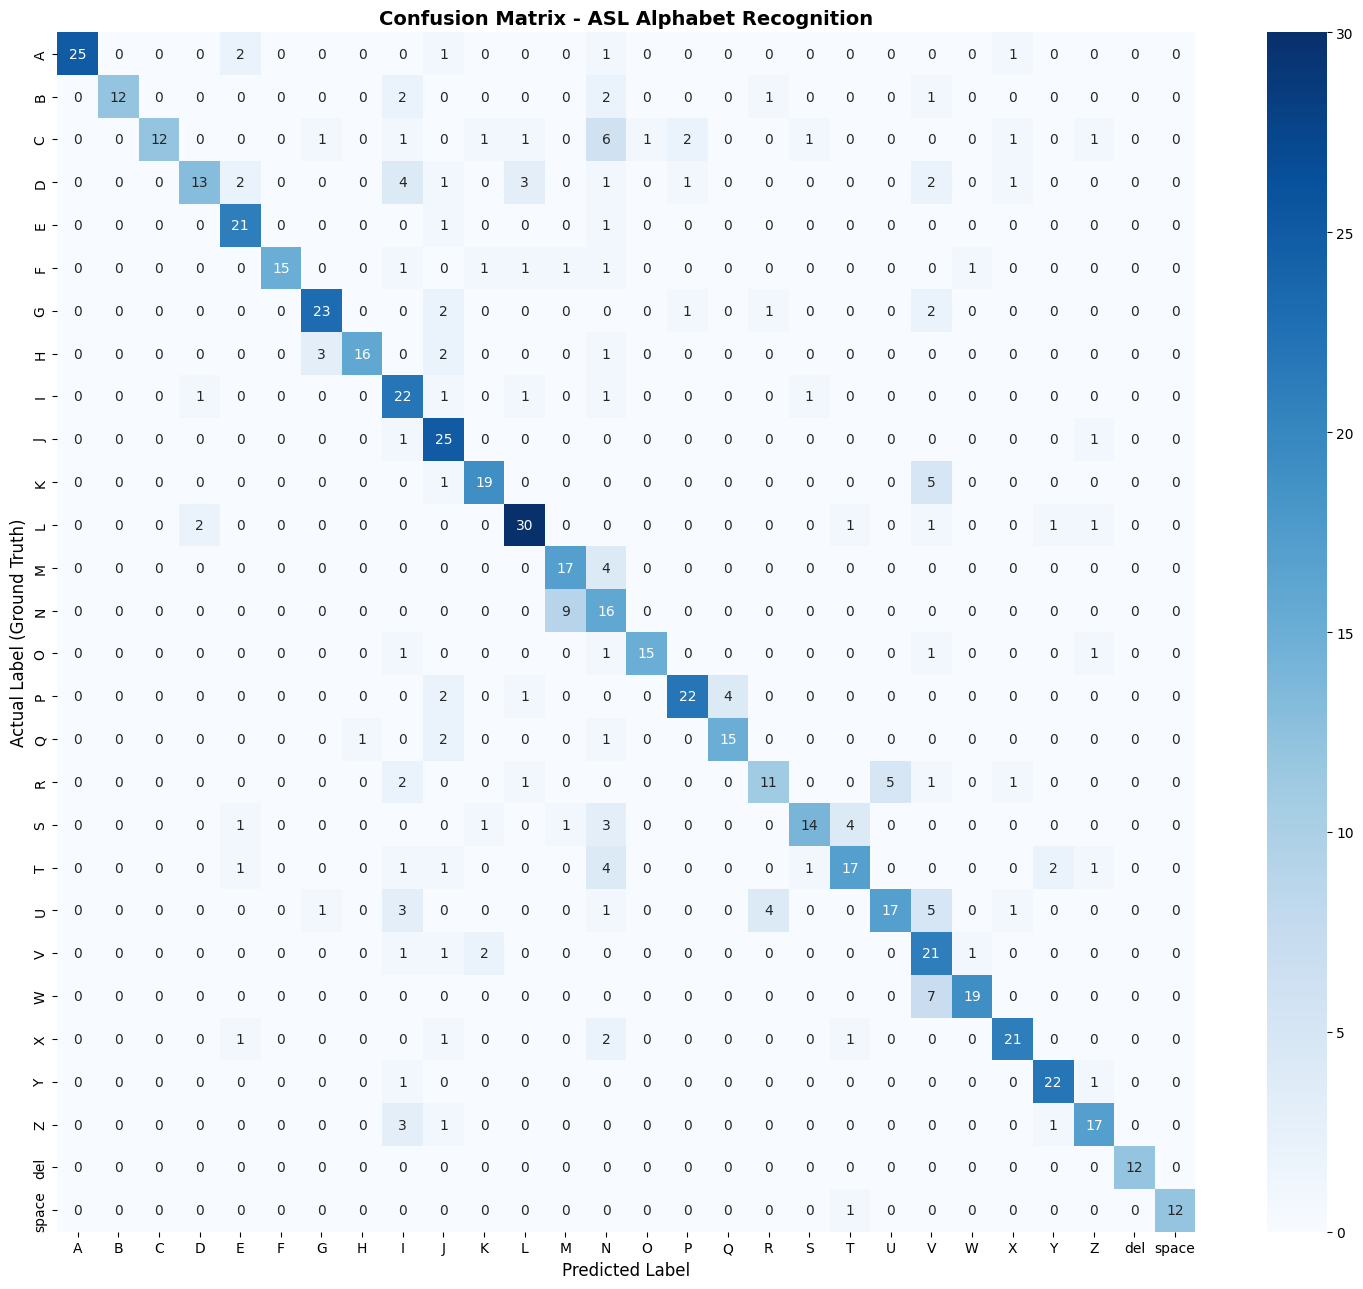

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Menghitung prediksi pada seluruh dataset validasi...")

# 1. Ekstrak seluruh gambar dan label asli dari validation_dataset
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    # Ambil indeks kelas dengan probabilitas softmax tertinggi
    preds_idx = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_idx)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Classification Report (Precision, Recall, F1-Score per kelas)
print("\n" + "="*60)
print(" CLASSIFICATION REPORT ")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Visualisasi Confusion Matrix dengan Seaborn Heatmap
print("\nGenerasi Heatmap Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 13))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - ASL Alphabet Recognition", fontsize=14, fontweight='bold')
plt.ylabel("Actual Label (Ground Truth)", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.show()

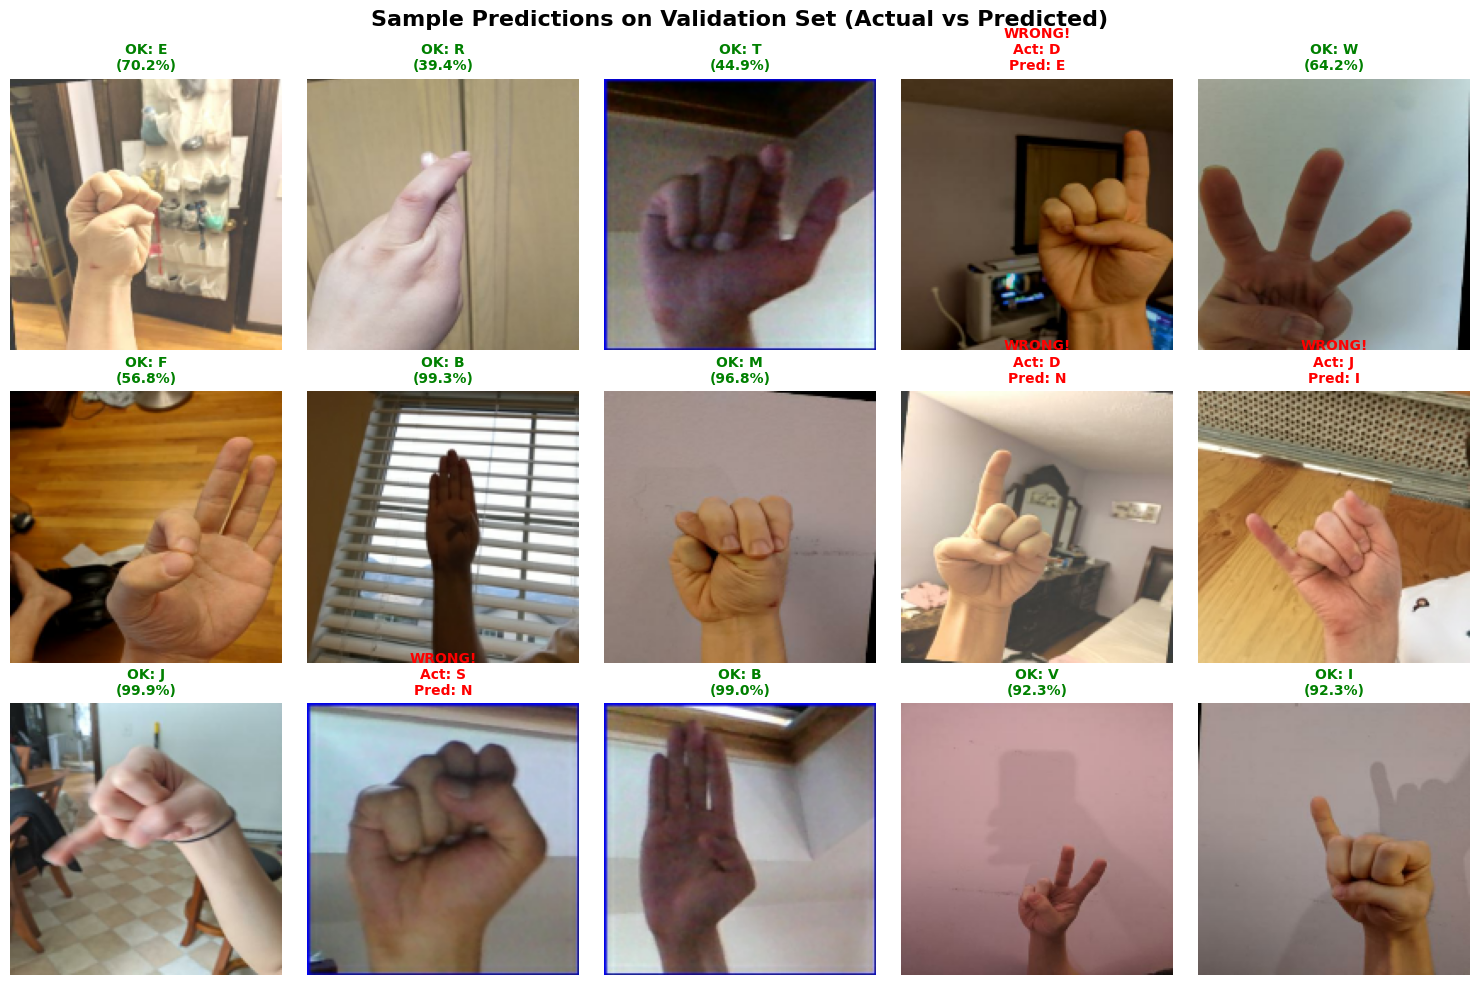

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ambil 1 batch secara acak dari validation_dataset
# Kita un-batch dulu lalu shuffle agar sampel yang muncul selalu bervariasi
visualization_ds = validation_dataset.unbatch().shuffle(buffer_size=100).batch(15)

for images, labels in visualization_ds.take(1):
    # Lakukan prediksi pada batch tersebut
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    plt.figure(figsize=(15, 10))

    # 2. Tampilkan 15 gambar dalam grid 3 baris x 5 kolom
    for i in range(15):
        ax = plt.subplot(3, 5, i + 1)

        # Kembalikan format gambar ke uint8 untuk visualisasi jika diperlukan
        img_display = images[i].numpy().astype("uint8")
        plt.imshow(img_display)

        actual_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes[i]]
        confidence = np.max(predictions[i]) * 100

        # 3. Logika penentuan warna judul (Hijau jika benar, Merah jika salah)
        if actual_label == predicted_label:
            title_text = f"OK: {predicted_label}\n({confidence:.1f}%)"
            title_color = "green"
        else:
            title_text = f"WRONG!\nAct: {actual_label}\nPred: {predicted_label}"
            title_color = "red"

        plt.title(title_text, color=title_color, fontsize=10, fontweight='bold')
        plt.axis("off")

    plt.suptitle("Sample Predictions on Validation Set (Actual vs Predicted)", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

## 6. Visualisasi Hasil Training

In [ ]:
def plot_summary(acc, val_acc, loss, val_loss) -> None:
    plt.figure(figsize=(8, 8))

    plt.subplot(2, 1, 1)
    plt.plot(acc, label="Training Accuracy")
    plt.plot(val_acc, label="Validation Accuracy")
    plt.ylim([0.0, 1.0])
    plt.plot(
        [INITIAL_EPOCHS - 1, INITIAL_EPOCHS - 1], plt.ylim(), label="Start Fine Tuning"
    )
    plt.legend(loc="lower left")
    plt.title("Training and Validation Accuracy")

    plt.subplot(2, 1, 2)
    plt.plot(loss, label="Training Loss")
    plt.plot(val_loss, label="Validation Loss")
    plt.ylim([0.0, 4.0])
    plt.plot(
        [INITIAL_EPOCHS - 1, INITIAL_EPOCHS - 1], plt.ylim(), label="Start Fine Tuning"
    )
    plt.legend(loc="lower left")
    plt.title("Training and Validation Loss")

    plt.xlabel("epoch")
    plt.tight_layout()
    plt.show()

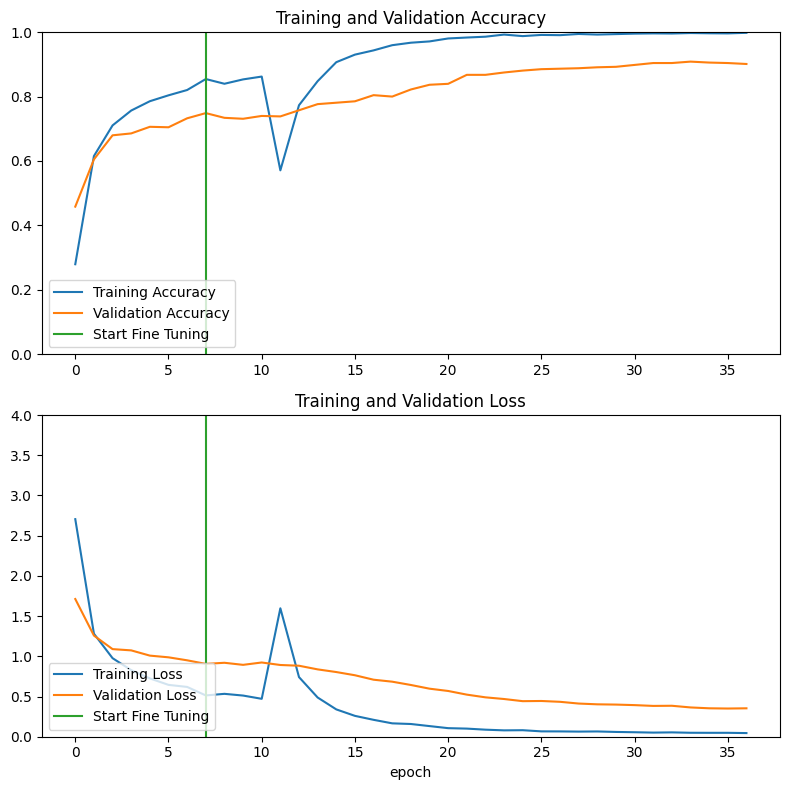

In [ ]:
acc = history.history["accuracy"] + fine_tune_history.history["accuracy"]
val_acc = history.history["val_accuracy"] + fine_tune_history.history["val_accuracy"]
loss = history.history["loss"] + fine_tune_history.history["loss"]
val_loss = history.history["val_loss"] + fine_tune_history.history["val_loss"]

plot_summary(acc, val_acc, loss, val_loss)

## 7. Simpan Model

In [ ]:
def get_representative_dataset(dataset):
    return itertools.islice(
        ([image[None, ...]] for images, _ in dataset for image in images),
        NUM_CALIBRATION_EXAMPLES,
    )


def save_model(model):
    """Simpan sebagai SavedModel dan TFLite."""
    tf.saved_model.save(model, CHECKPOINT_PATH)
    print(f"SavedModel disimpan ke: {CHECKPOINT_PATH}")

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    if OPTIMIZE_TFLITE:
        converter.optimizations = {tf.lite.Optimize.DEFAULT}
        if NUM_CALIBRATION_EXAMPLES:
            converter.representative_dataset = get_representative_dataset
    lite_model_content = converter.convert()

    tflite_path = os.path.join(CHECKPOINT_PATH, TFLITE_FNAME)
    with open(tflite_path, "wb") as f:
        f.write(lite_model_content)
    print(f"TFLite model disimpan ke: {tflite_path}")

In [ ]:
save_model(model)

## 8. (Opsional) Evaluasi Model

Uncomment cell berikut untuk menjalankan evaluasi perbandingan antara model Keras dan TFLite.

In [ ]:
def load_model_tflite():
    interpreter = tf.lite.Interpreter(
        model_path=os.path.join(CHECKPOINT_PATH, TFLITE_FNAME)
    )
    classify_lite = interpreter.get_signature_runner("serving_default")
    return classify_lite


def evaluate_model(model, dataset):
    y_pred, y_true = [], []
    for images, labels in dataset:
        for image, label in zip(images, labels):
            y_pred.append(np.argmax(model(image[None, ...]).numpy()[0]))
            y_true.append(label.numpy())
    return y_pred, y_true


def evaluate_tflite(classify_lite, dataset):
    y_pred, y_true = [], []
    for images, labels in dataset:
        for image, label in zip(images, labels):
            y_pred.append(
                np.argmax(classify_lite(input_2=image[None, ...])["outputs"])
            )
            y_true.append(label.numpy())
    return y_pred, y_true


# Jalankan evaluasi
model_predictions, model_labels = evaluate_model(model, validation_dataset)
classify_lite = load_model_tflite()
tflite_predictions, tflite_labels = evaluate_tflite(classify_lite, validation_dataset)

results = [
    {
        "true": class_names[ml],
        "model_pred": class_names[mp],
        "tflite_pred": class_names[tp],
    }
    for ml, mp, tp in zip(model_labels, model_predictions, tflite_predictions)
]

# Tampilkan sebagian hasil
for r in results[:10]:
    print(r)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


ValueError: Could not open './checkpoint/model.tflite'.